# Notebook 02 - Local Causal Propagation Analysis

This notebook runs local causal discovery for the selected NSW benchmark case. This uses the prepared NSW local benchmark files generated in `01_prepare_causal_analysis.ipynb`.

## Benchmark Objective

This task evaluates a causal discovery method's ability to characterize local traffic propagation surrounding a verified traffic incident.

**Input**: Selected incident; Local road subgraph; One-year historical traffic flow.
**Output**: Local causal graph; Station-level anomaly analysis; Historical traffic baseline; Incident interpretation.

### Steps
1.	Extract an incident data and local subgraph around the incident (local benchmark case generated by **Notebook 01 - Local Benchmark Construction**). 
2.	Characterize traffic changes relative to a historical baseline. 
3.	Infer historical causal relationships using PCMCI. 
4.	Assess cross-method robustness using Granger causality. 
5.	Produce a benchmark report. 

## 1. Import libraries and define paths
Load all required libraries and define the benchmark directory structure.

In [ ]:
from pathlib import Path
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Road Map
import folium

# PCMCI Method
from tigramite import data_processing as pp
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.pcmci import PCMCI
from tigramite import plotting as tp

# Granger Method
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.multitest import multipletests
import time
import warnings

# Spearman rank correlation
from scipy.stats import spearmanr

LOCAL_DIR = Path("data")

# Create output folder
FIG_DIR = Path("results")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Local Benchmark Files

In [187]:
sensor_meta = pd.read_csv(LOCAL_DIR / "sensor_meta_info_local.csv")
incidents_local = pd.read_csv(LOCAL_DIR / "incidents_local.csv")
local_graph_info = pd.read_csv(LOCAL_DIR / "local_graph_info.csv")
case_summary = pd.read_csv(LOCAL_DIR / "local_case_summary.csv")

raw_flow_local = np.load(LOCAL_DIR / "raw_flow_local.npy")
flow_matrix = pd.read_csv(LOCAL_DIR / "raw_flow_local.csv",
    index_col=0,
    parse_dates=True
)

print("sensor_meta:", sensor_meta.shape)
print("incidents_local:", incidents_local.shape)
print("local_graph_info:", local_graph_info.shape)
print("case_summary:", case_summary.shape)
print("raw_flow_local:", raw_flow_local.shape)
print("flow_matrix:", flow_matrix.shape)

case_summary

sensor_meta: (5, 11)
incidents_local: (366, 26)
local_graph_info: (5, 2)
case_summary: (1, 12)
raw_flow_local: (8760, 5)
flow_matrix: (8760, 5)


,selected_incident,selected_station,hazard_type,major_incident,incident_duration_hours,incident_distance_km,max_impact_hour,hourly_records,num_local_stations,num_local_incidents,num_flow_hours,flow_variables
0,240298-webtirf,7119-PR,CRASH,1,3.304605,0.004,3,4,5,281,8760,5


## 3. Validate Local Data Alignment

Confirm that the columns of the traffic-flow matrix match the local graph station order.

In [188]:
selected_stations = local_graph_info["station_id"].astype(str).tolist()

print("Selected stations:")
print(selected_stations)

print("\nFlow columns:")
print(flow_matrix.columns.tolist())

print("\nColumn order matches local graph:",
      selected_stations == flow_matrix.columns.astype(str).tolist())

print("Missing flow values:", flow_matrix.isna().sum().sum())

Selected stations:
['7119-PR', '50240', '68025', '7164', '7179']

Flow columns:
['7119-PR', '50240', '68025', '7164', '7179']

Column order matches local graph: True
Missing flow values: 0


## 4. Define Local Incident Window

The selected incident is used to define a local event window for causal analysis. We extract traffic flow before, during, and after the incident.

In [189]:
selected_incident = case_summary.loc[0, "selected_incident"]
selected_station = str(case_summary.loc[0, "selected_station"])

selected_incident_records = incidents_local[
    incidents_local["incident_id"] == selected_incident
].copy()

selected_incident_records["match_hour"] = pd.to_datetime(
    selected_incident_records["match_hour"],
    format="mixed",
    errors="coerce"
)

incident_start = selected_incident_records["match_hour"].min()
incident_end = selected_incident_records["match_hour"].max()

print("Selected incident:", selected_incident)
print("Selected station:", selected_station)
print("Incident start:", incident_start)
print("Incident end:", incident_end)

pre_hours = 24
post_hours = 24

before_start = incident_start - pd.Timedelta(hours=pre_hours)
before_end = incident_start - pd.Timedelta(hours=1)

after_start = incident_start
after_end = incident_end + pd.Timedelta(hours=post_hours)

before_data_df = flow_matrix.loc[before_start:before_end].copy()
after_data_df = flow_matrix.loc[after_start:after_end].copy()

before_data = before_data_df.values
after_data = after_data_df.values

print("\nBefore window:", before_start, "to", before_end)
print("Before data shape:", before_data.shape)

print("\nAfter window:", after_start, "to", after_end)
print("After data shape:", after_data.shape)

Selected incident: 240298-webtirf
Selected station: 7119-PR
Incident start: 2025-06-26 08:00:00
Incident end: 2025-06-26 11:00:00

Before window: 2025-06-25 08:00:00 to 2025-06-26 07:00:00
Before data shape: (24, 5)

After window: 2025-06-26 08:00:00 to 2025-06-27 11:00:00
After data shape: (28, 5)


## 5. Traffic Flow Before, During, and After the Incident



### 5.1 Summary Traffic Flow


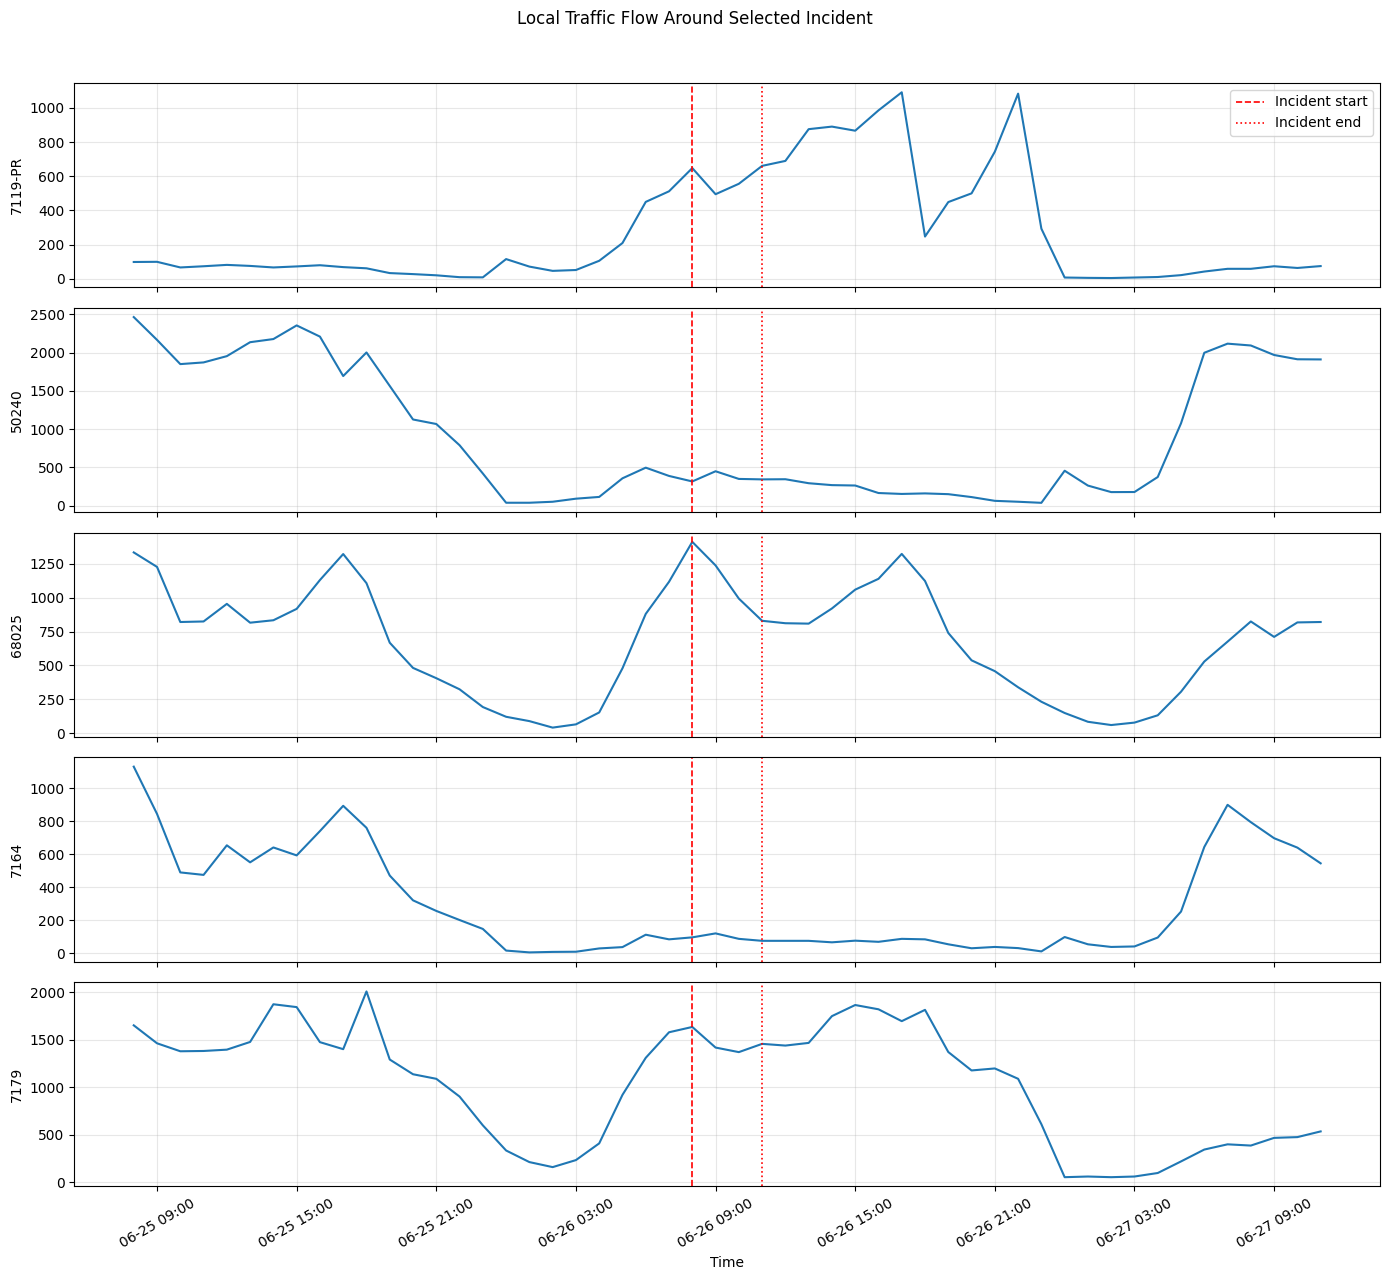

In [190]:
plot_start = incident_start - pd.Timedelta(hours=24)
plot_end = incident_end + pd.Timedelta(hours=24)

flow_plot = flow_matrix.loc[plot_start:plot_end].copy()

fig, axes = plt.subplots(
    len(selected_stations),
    1,
    figsize=(14, 2.5 * len(selected_stations)),
    sharex=True
)

for i, station in enumerate(selected_stations):
    axes[i].plot(flow_plot.index, flow_plot[station])
    
    axes[i].axvline(
        incident_start,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label="Incident start" if i == 0 else None
    )
    
    axes[i].axvline(
        incident_end,
        color="red",
        linestyle=":",
        linewidth=1.2,
        label="Incident end" if i == 0 else None
    )
    
    axes[i].set_ylabel(station)
    axes[i].grid(True, alpha=0.3)

axes[0].legend(loc="upper right")

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=6))

plt.xticks(rotation=30)

fig.suptitle(
    "Local Traffic Flow Around Selected Incident",
    y=1.02
)

plt.tight_layout()
plt.show()

In [191]:
before_df = flow_matrix.loc[before_start:before_end].copy()
during_df = flow_matrix.loc[incident_start:incident_end].copy()
after_df = flow_matrix.loc[incident_end + pd.Timedelta(hours=1):after_end].copy()

impact_summary = pd.DataFrame({
    "station_id": flow_matrix.columns,
    "before_mean": before_df.mean().values,
    "during_mean": during_df.mean().values,
    "after_mean": after_df.mean().values
})

impact_summary["during_minus_before"] = (
    impact_summary["during_mean"] - impact_summary["before_mean"]
)

impact_summary["after_minus_before"] = (
    impact_summary["after_mean"] - impact_summary["before_mean"]
)

impact_summary["during_pct_change"] = (
    impact_summary["during_minus_before"] / impact_summary["before_mean"]
) * 100

impact_summary["after_pct_change"] = (
    impact_summary["after_minus_before"] / impact_summary["before_mean"]
) * 100

impact_summary

,station_id,before_mean,during_mean,after_mean,during_minus_before,after_minus_before,during_pct_change,after_pct_change
0,7119-PR,103.916667,590.00,380.875000,486.083333,276.958333,467.762630,266.519647
1,50240,1225.708333,365.25,691.458333,-860.458333,-534.250000,-70.200904,-43.587042
2,68025,679.750000,1119.00,611.916667,439.250000,-67.833333,64.619345,-9.979159
3,7164,394.916667,95.50,229.625000,-299.416667,-165.291667,-75.817683,-41.854822
4,7179,1147.958333,1471.00,852.958333,323.041667,-295.000000,28.140539,-25.697797


### 5.2 Rank Stations by Incident Impact

Stations are ranked by the absolute percentage change between the pre-incident and incident periods. This identifies which stations experienced the largest traffic disruption during the selected crash.

In [192]:
impact_rank = impact_summary.copy()
impact_rank["abs_during_pct_change"] = impact_rank["during_pct_change"].abs()

impact_rank = impact_rank.sort_values(
    "abs_during_pct_change",
    ascending=False
)

impact_rank

,station_id,before_mean,during_mean,after_mean,during_minus_before,after_minus_before,during_pct_change,after_pct_change,abs_during_pct_change
0,7119-PR,103.916667,590.00,380.875000,486.083333,276.958333,467.762630,266.519647,467.762630
3,7164,394.916667,95.50,229.625000,-299.416667,-165.291667,-75.817683,-41.854822,75.817683
1,50240,1225.708333,365.25,691.458333,-860.458333,-534.250000,-70.200904,-43.587042,70.200904
2,68025,679.750000,1119.00,611.916667,439.250000,-67.833333,64.619345,-9.979159,64.619345
4,7179,1147.958333,1471.00,852.958333,323.041667,-295.000000,28.140539,-25.697797,28.140539


### 5.3 Compare Incident Flow Against Historical Traffic Baseline

The previous comparison uses the 24 hours before the incident as the baseline. However, traffic flow varies naturally by weekday and time of day. To create a stronger counterfactual baseline, this step compares the incident-period flow with the Historical Traffic Baseline observed at the same weekday and hour across the full year, excluding the incident day.

This provides an estimate of how unusual the traffic flow was during the selected incident.

In [193]:
incident_date = incident_start.date()
incident_weekday = incident_start.weekday()

incident_hours = list(
    pd.date_range(
        incident_start,
        incident_end,
        freq="h"
    ).hour
)

baseline_candidates = flow_matrix.copy()

baseline_candidates["weekday"] = baseline_candidates.index.weekday
baseline_candidates["hour"] = baseline_candidates.index.hour
baseline_candidates["date"] = baseline_candidates.index.date

historical_baseline = baseline_candidates[
    (baseline_candidates["weekday"] == incident_weekday) &
    (baseline_candidates["hour"].isin(incident_hours)) &
    (baseline_candidates["date"] != incident_date)
].drop(columns=["weekday", "hour", "date"])

historical_mean = historical_baseline.mean()

incident_mean = during_df.mean()

historical_comparison = pd.DataFrame({
    "station_id": flow_matrix.columns,
    "historical_same_weekday_hour": historical_mean.values,
    "incident_period_mean": incident_mean.values
})

historical_comparison["incident_minus_historical"] = (
    historical_comparison["incident_period_mean"] -
    historical_comparison["historical_same_weekday_hour"]
)

historical_comparison["incident_pct_change_from_historical"] = (
    historical_comparison["incident_minus_historical"] /
    historical_comparison["historical_same_weekday_hour"]
) * 100

historical_comparison = historical_comparison.sort_values(
    "incident_pct_change_from_historical",
    key=lambda x: x.abs(),
    ascending=False
)

historical_comparison

,station_id,historical_same_weekday_hour,incident_period_mean,incident_minus_historical,incident_pct_change_from_historical
2,68025,527.245098,1119.00,591.754902,112.235259
4,7179,870.750000,1471.00,600.250000,68.934826
3,7164,261.250000,95.50,-165.750000,-63.444976
1,50240,842.960784,365.25,-477.710784,-56.670582
0,7119-PR,415.313725,590.00,174.686275,42.061281


### 5.4 Visualize Incident Impact Ranking

This bar chart shows the percentage change in traffic flow during the incident. Negative values indicate traffic reduction, while positive values indicate increased flow, which may suggest diversion or congestion redistribution.

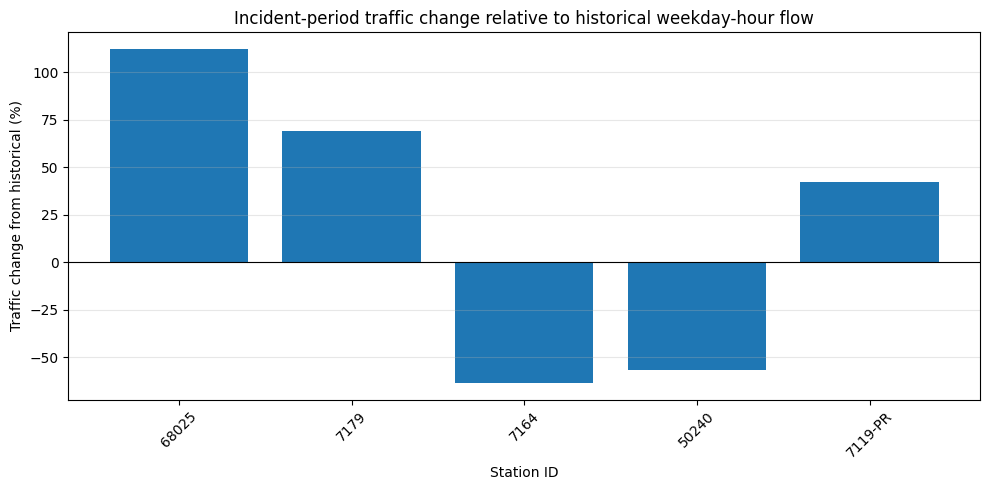

In [194]:
plt.figure(figsize=(10, 5))

plt.bar(
    historical_comparison["station_id"],
    historical_comparison["incident_pct_change_from_historical"]
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Station ID")
plt.ylabel("Traffic change from historical (%)")
plt.title("Incident-period traffic change relative to historical weekday-hour flow")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "incident_impact_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.5 Compare Observed Incident Flow with Historical Weekday-Hour Baseline

The previous bar chart summarizes the average difference between incident-period flow and historical traffic conditions baseline. To better understand whether the incident period follows or deviates from the usual daily traffic pattern, this step compares the observed traffic flow around the selected incident with the historical flow for the same weekday and hour.

In [195]:
plot_start = incident_start - pd.Timedelta(hours=24)
plot_end = incident_end + pd.Timedelta(hours=24)

observed_window = flow_matrix.loc[plot_start:plot_end].copy()

# Build historical weekday-hour profile for the same timestamps
historical_window = pd.DataFrame(
    index=observed_window.index,
    columns=observed_window.columns,
    dtype=float
)

for ts in observed_window.index:
    same_weekday = flow_matrix.index.weekday == ts.weekday()
    same_hour = flow_matrix.index.hour == ts.hour
    not_incident_date = flow_matrix.index.date != incident_start.date()
    
    baseline_rows = flow_matrix.loc[
        same_weekday & same_hour & not_incident_date
    ]
    
    historical_window.loc[ts] = baseline_rows.mean()

print("Observed window:", observed_window.shape)
print("historical window:", historical_window.shape)
print("Missing historical values:", historical_window.isna().sum().sum())

Observed window: (52, 5)
historical window: (52, 5)
Missing historical values: 0


This plot shows the hourly traffic flow for the selected station and its neighbours across the incident window. The x-axis represents time, while each subplot corresponds to one traffic station in the local graph. The red dashed vertical lines indicate the incident start and end times.

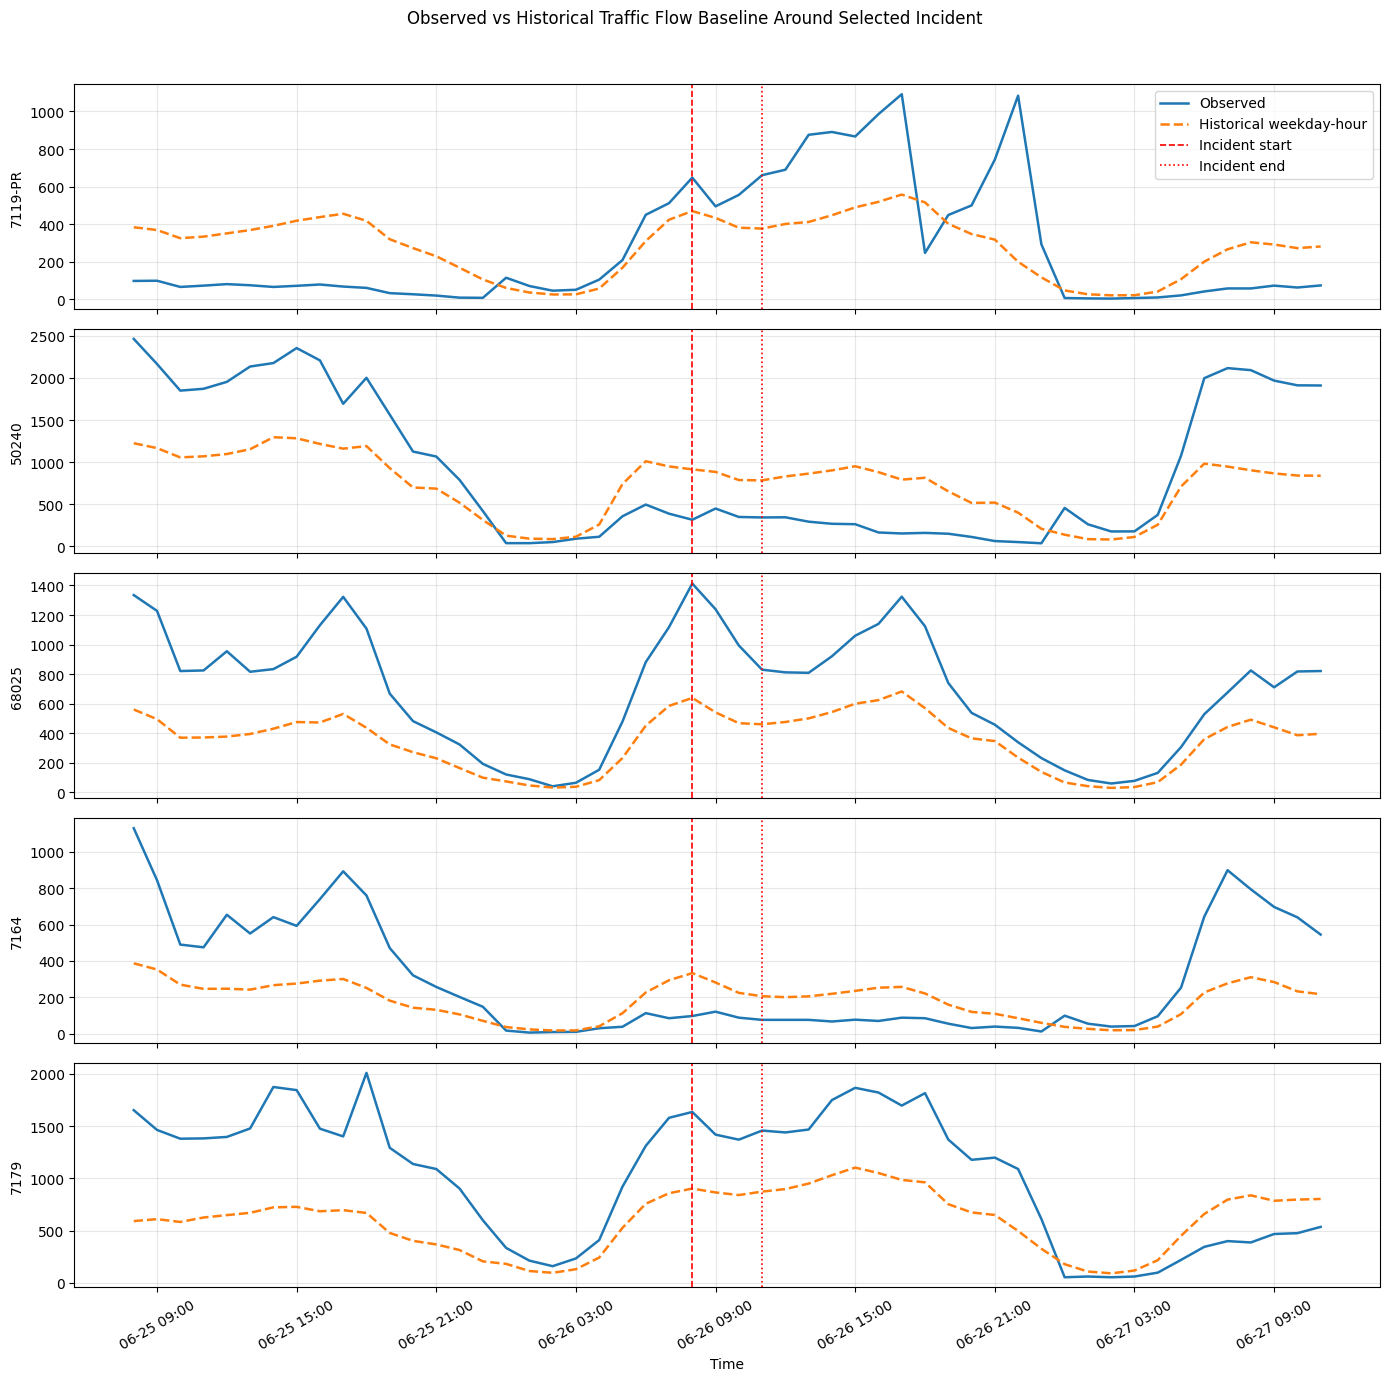

In [196]:
fig, axes = plt.subplots(
    len(selected_stations),
    1,
    figsize=(14, 2.7 * len(selected_stations)),
    sharex=True
)

if len(selected_stations) == 1:
    axes = [axes]

for i, station in enumerate(selected_stations):
    axes[i].plot(
        observed_window.index,
        observed_window[station],
        label="Observed",
        linewidth=1.8
    )
    
    axes[i].plot(
        historical_window.index,
        historical_window[station],
        label="Historical weekday-hour",
        linestyle="--",
        linewidth=1.8
    )
    
    axes[i].axvline(
        incident_start,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label="Incident start" if i == 0 else None
    )
    
    axes[i].axvline(
        incident_end,
        color="red",
        linestyle=":",
        linewidth=1.2,
        label="Incident end" if i == 0 else None
    )
    
    axes[i].set_ylabel(station)
    axes[i].grid(True, alpha=0.3)

axes[0].legend(loc="upper right")

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=6))

plt.xticks(rotation=30)

fig.suptitle(
    "Observed vs Historical Traffic Flow Baseline Around Selected Incident",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "observed_vs_historical_incident_window.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.6 Calculate Abnormal Flow During the Incident Window

This step calculates the difference between observed traffic flow and the historical weekday-hour baseline. Positive values indicate higher-than-usual flow during the incident period, while negative values indicate lower-than-usual flow.

In [197]:
observed_during = observed_window.loc[incident_start:incident_end]
historical_during = historical_window.loc[incident_start:incident_end]

abnormal_during = observed_during - historical_during

abnormal_summary = pd.DataFrame({
    "station_id": selected_stations,
    "observed_incident_mean": observed_during.mean().values,
    "historical_incident_mean": historical_during.mean().values,
    "abnormal_flow": abnormal_during.mean().values
})

abnormal_summary["abnormal_pct_change"] = (
    abnormal_summary["abnormal_flow"] /
    abnormal_summary["historical_incident_mean"]
) * 100

abnormal_summary["abs_abnormal_flow"] = abnormal_summary["abnormal_flow"].abs()
abnormal_summary["abs_abnormal_pct_change"] = abnormal_summary["abnormal_pct_change"].abs()

abnormal_summary = abnormal_summary.sort_values(
    "abs_abnormal_flow",
    ascending=False
)

abnormal_summary

,station_id,observed_incident_mean,historical_incident_mean,abnormal_flow,abnormal_pct_change,abs_abnormal_flow,abs_abnormal_pct_change
4,7179,1471.00,870.750000,600.250000,68.934826,600.250000,68.934826
2,68025,1119.00,527.245098,591.754902,112.235259,591.754902,112.235259
1,50240,365.25,842.960784,-477.710784,-56.670582,477.710784,56.670582
0,7119-PR,590.00,415.313725,174.686275,42.061281,174.686275,42.061281
3,7164,95.50,261.250000,-165.750000,-63.444976,165.750000,63.444976


## 6. PCMCI

### 6.1. Prepare Data for PCMCI

In [198]:
variable_names = flow_matrix.columns.tolist()

print("Variables:")
print(variable_names)

print("Number of variables:", len(variable_names))
print("Number of observations:", len(flow_matrix))

Variables:
['7119-PR', '50240', '68025', '7164', '7179']
Number of variables: 5
Number of observations: 8760


In [199]:
# Validate the input time-series matrix
flow_matrix = flow_matrix.sort_index()

print("Shape:", flow_matrix.shape)
print("Missing values:", flow_matrix.isna().sum().sum())
print("Duplicated columns:", flow_matrix.columns.duplicated().sum())
print("Constant variables:", flow_matrix.columns[flow_matrix.nunique() <= 1].tolist())

if flow_matrix.isna().any().any():
    raise ValueError("flow_matrix contains missing values.")

if flow_matrix.columns.duplicated().any():
    raise ValueError("flow_matrix contains duplicated station columns.")

if not np.isfinite(flow_matrix.to_numpy()).all():
    raise ValueError("flow_matrix contains infinite values.")

Shape: (8760, 5)
Missing values: 0
Duplicated columns: 0
Constant variables: []


In [200]:
# Create the Tigramite dataframe:
tigramite_df = pp.DataFrame(
    flow_matrix.values,
    datatime=np.arange(len(flow_matrix)),
    var_names=variable_names
)

print(tigramite_df)

### 6.2. Configure the PCMCI Model

The Tigramite PCMCI algorithm is configured to estimate lagged causal relationships among the local traffic stations. The traffic flow at each station is treated as one variable in a multivariate time series, and conditional independence is evaluated using partial correlation.

In [201]:
# Conditional independence test
cond_ind_test = ParCorr(significance="analytic")

# Create PCMCI object
pcmci = PCMCI(
    dataframe=tigramite_df,
    cond_ind_test=cond_ind_test,
    verbosity=1
)

### 6.3. Run Causal Discovery

PCMCI is applied to the local traffic time series to estimate statistically significant lagged causal relationships among neighbouring traffic stations. A significance level of 0.05 is used to determine the final causal graph.

The maximum lag (`tau_max`) defines the longest temporal dependency considered during causal discovery. Since the NSW dataset has hourly observations, a maximum lag of six hours is adopted to capture short-term traffic propagation while limiting unnecessary model complexity.

In [202]:
alpha_level = 0.05
tau_max = 6

results = pcmci.run_pcmci(
    tau_max=tau_max,
    pc_alpha=alpha_level
)


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 6
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable 7119-PR has 11 link(s):
        (7119-PR -1): max_pval = 0.00000, |min_val| =  0.797
        (7119-PR -2): max_pval = 0.00000, |min_val| =  0.158
        (7119-PR -3): max_pval = 0.00000, |min_val| =  0.076
        (68025 -2): max_pval = 0.00904, |min_val| =  0.028
        (7179 -3): max_pval = 0.01027, |min_val| =  0.027
        (7179 -4): max_pval = 0.01441, |min_val| =  0.026
        (7179 -2): max_pval = 0.01600, |min_val| =  0.026
        (7119-PR -6): max_pval = 0.01680, |min_val| =  0.026
        (50240 -4): max_pval = 0.01747, |min_val| =  0.025
        (50240 -5): max_pval = 0.02057, |min_val| =  0.025
        (68025 -3): max_pval = 0.03906, |min_val| =  0.022

    Variable 50240 has 9 link(s):
        (50240 -1): max_pval = 0.00000, 

### 6.4. Extract Significant Causal Relationships

The PCMCI output contains the estimated causal strength (`val_matrix`) and the corresponding statistical significance (`p_matrix`) for every pair of stations and temporal lag. This step extracts only statistically significant causal links for subsequent visualization and interpretation.

In [203]:
alpha_level = 0.05

pcmci.print_significant_links(
    p_matrix=results["p_matrix"],
    val_matrix=results["val_matrix"],
    alpha_level=alpha_level
)


## Significant links at alpha = 0.05:

    Variable 7119-PR has 20 link(s):
        (7119-PR -1): pval = 0.00000 | val =  0.796
        (68025  0): pval = 0.00000 | val =  0.230
        (7164  0): pval = 0.00000 | val =  0.228
        (7179  0): pval = 0.00000 | val =  0.202
        (50240  0): pval = 0.00000 | val =  0.168
        (7119-PR -2): pval = 0.00000 | val = -0.155
        (7179 -1): pval = 0.00000 | val =  0.132
        (50240 -1): pval = 0.00000 | val =  0.117
        (68025 -1): pval = 0.00000 | val =  0.081
        (7119-PR -3): pval = 0.00000 | val = -0.076
        (7179 -2): pval = 0.00000 | val =  0.074
        (7164 -1): pval = 0.00000 | val =  0.073
        (50240 -4): pval = 0.00000 | val = -0.055
        (7119-PR -5): pval = 0.00000 | val =  0.052
        (50240 -2): pval = 0.00001 | val =  0.049
        (68025 -2): pval = 0.00004 | val = -0.044
        (7179 -4): pval = 0.00071 | val = -0.036
        (7164 -2): pval = 0.00413 | val = -0.031
        (68025 -3): pv

### 6.5. Inspect PCMCI Output

In [204]:
print(results.keys())
print("Graph matrix:", results["graph"].shape)
print("P-value matrix:", results["p_matrix"].shape)
print("Value matrix:", results["val_matrix"].shape)

dict_keys(['graph', 'p_matrix', 'val_matrix', 'conf_matrix'])
Graph matrix: (5, 5, 7)
P-value matrix: (5, 5, 7)
Value matrix: (5, 5, 7)


### 6.6. Visualize the Local Causal Network

The significant causal relationships estimated by PCMCI are visualized as a directed network. Each node represents a traffic station in the local benchmark graph, while directed edges indicate statistically significant lagged causal influences between stations.

Edge colours represent the direction and magnitude of the estimated causal effect (`val_matrix`), and edge widths are proportional to the causal strength. The resulting network provides an intuitive representation of how traffic conditions propagate across neighbouring stations.

<Figure size 1000x800 with 0 Axes>

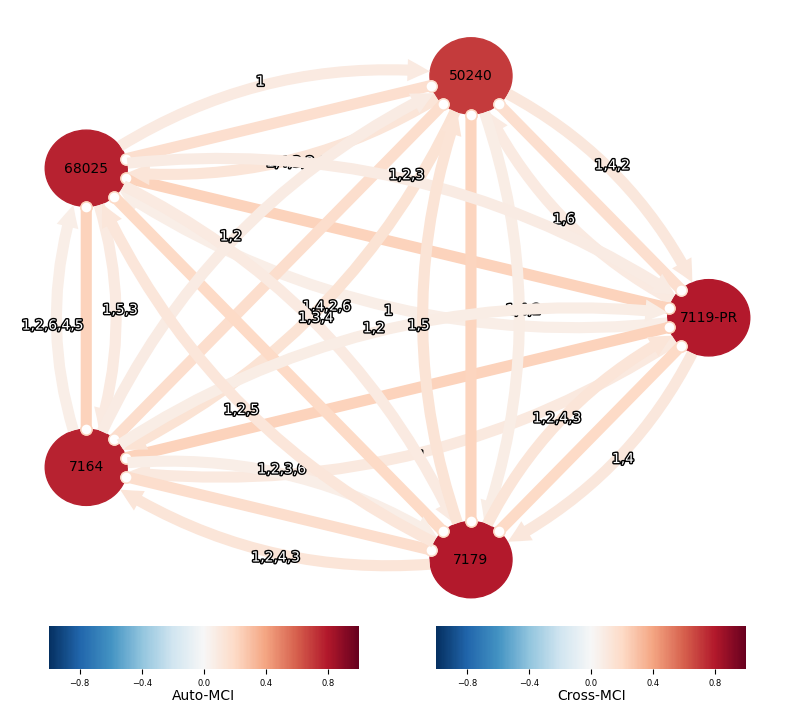

In [205]:
fig = plt.figure(figsize=(10, 8))

tp.plot_graph(
    val_matrix=results["val_matrix"],
    graph=results["graph"],
    var_names=variable_names,
    figsize=(10, 8),
    link_colorbar_label="Cross-MCI",
    node_colorbar_label="Auto-MCI"
)

plt.savefig(
    FIG_DIR / "local_causal_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.7. Visualize Lagged Causal Effects

The lag-function plots illustrate how the causal influence between stations changes across temporal lags. Peaks at specific lags indicate the delay with which traffic conditions propagate between neighbouring stations.

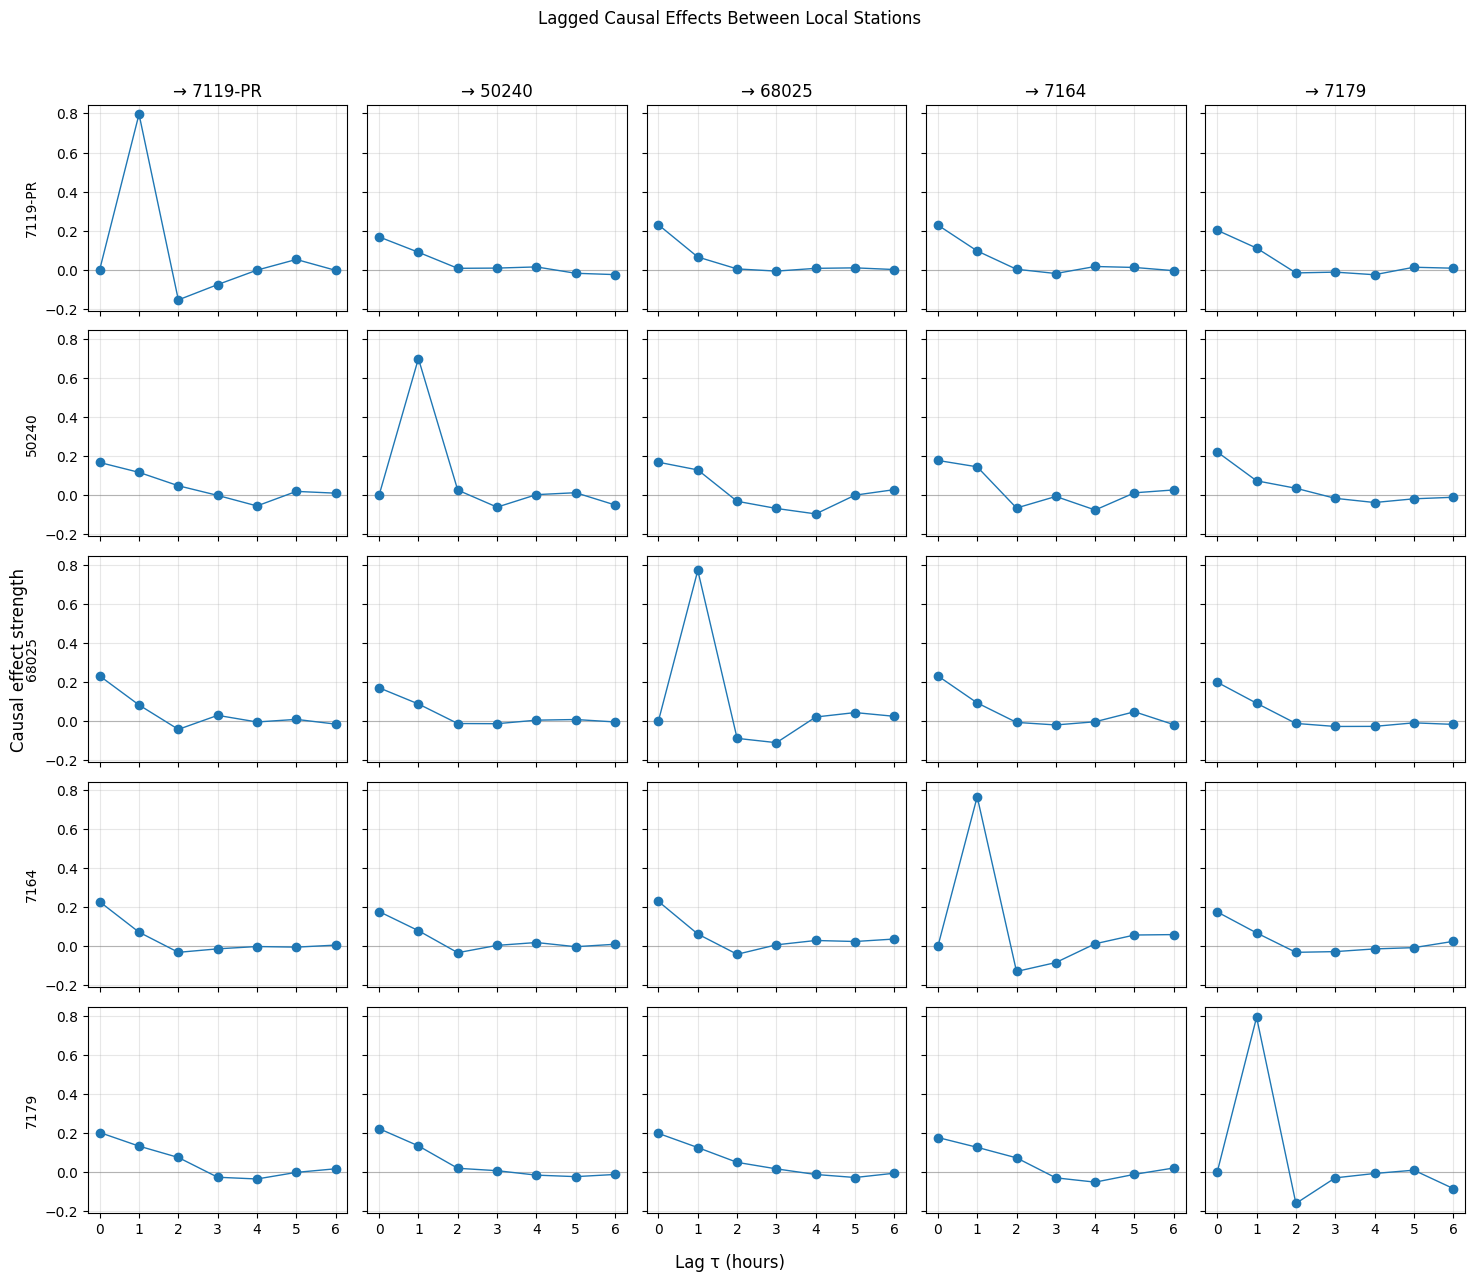

In [206]:
val_matrix = results["val_matrix"]
n_vars = len(variable_names)
tau_max = val_matrix.shape[2] - 1
lags = range(tau_max + 1)

fig, axes = plt.subplots(
    n_vars,
    n_vars,
    figsize=(3 * n_vars, 2.5 * n_vars),
    sharex=True,
    sharey=True
)

for source in range(n_vars):
    for target in range(n_vars):
        ax = axes[source, target]
        
        ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
        ax.plot(
            lags,
            val_matrix[source, target, :],
            marker="o",
            linewidth=1
        )
        
        if source == 0:
            ax.set_title(f"→ {variable_names[target]}")
        
        if target == 0:
            ax.set_ylabel(variable_names[source])
        
        ax.set_xticks(list(lags))
        ax.grid(True, alpha=0.3)

fig.supxlabel("Lag τ (hours)")
fig.supylabel("Causal effect strength")
fig.suptitle("Lagged Causal Effects Between Local Stations", y=1.02)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "lag_functions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.8. Export Significant Causal Links

In [207]:
alpha = 0.05
links = []
graph = results["graph"]
p = results["p_matrix"]
val = results["val_matrix"]

for source in range(len(variable_names)):
    for target in range(len(variable_names)):
        for tau in range(1, graph.shape[2]):   # ignore lag 0

            if p[source, target, tau] < alpha:

                links.append({
                    "source_station": variable_names[source],
                    "target_station": variable_names[target],
                    "lag_hour": tau,
                    "effect_size": val[source, target, tau],
                    "p_value": p[source, target, tau]
                })

links = pd.DataFrame(links)

links = links.sort_values(
    "effect_size",
    key=np.abs,
    ascending=False
)

links.head(20)

,source_station,target_station,lag_hour,effect_size,p_value
0,7119-PR,7119-PR,1,0.796339,0.000000e+00
75,7179,7179,1,0.791914,0.000000e+00
33,68025,68025,1,0.770295,0.000000e+00
53,7164,7164,1,0.766081,0.000000e+00
13,50240,50240,1,0.700043,0.000000e+00
76,7179,7179,2,-0.161453,4.189755e-52
1,7119-PR,7119-PR,2,-0.154801,5.959650e-48
22,50240,7164,1,0.145413,1.826480e-42
66,7179,50240,1,0.133253,6.808022e-36
62,7179,7119-PR,1,0.132082,2.756957e-35


In [208]:
links.to_csv(
    FIG_DIR / "significant_links.csv",
    index=False
)

print("Number of significant lagged links:", len(links))

Number of significant lagged links: 79


### 6.9. Visualize Strongest Cross-Station Causal Links

To improve interpretability, this step keeps only the strongest cross-station lagged causal links. Self-lag relationships are excluded from this visualization.

In [209]:
effect_threshold = 0.10
strong_graph = results["graph"].copy()
strong_graph[np.abs(results["val_matrix"]) < effect_threshold] = ""

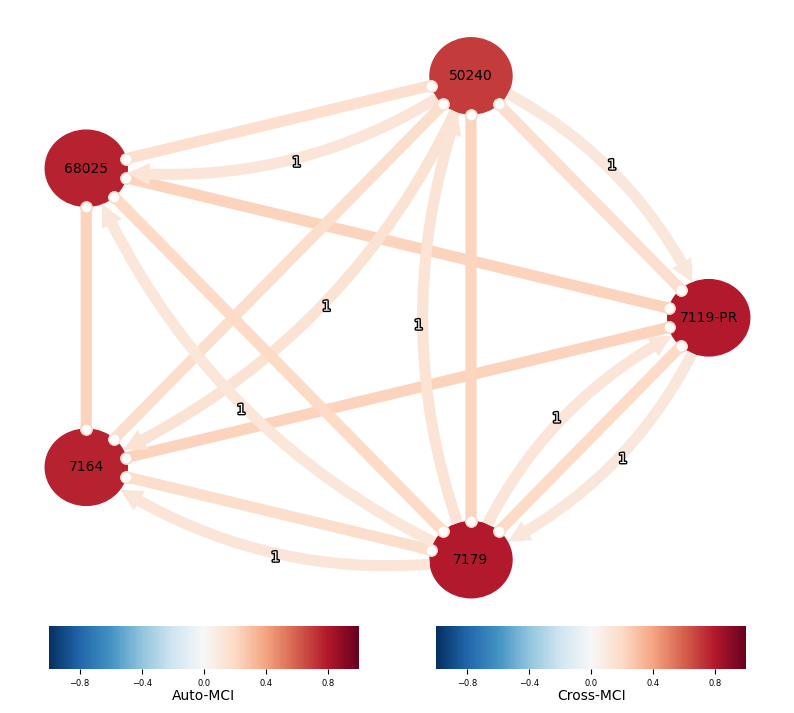

In [210]:
tp.plot_graph(
    graph=strong_graph,
    val_matrix=results["val_matrix"],
    var_names=variable_names,
    figsize=(10,8),
    link_colorbar_label="Cross-MCI",
    node_colorbar_label="Auto-MCI"
)

plt.savefig(
    FIG_DIR / "local_causal_graph_strong.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [211]:
strong_links = links[
    np.abs(links["effect_size"]) >= effect_threshold
].copy()

print("Strong links:", len(strong_links))

display(strong_links.head(20))

strong_links.to_csv(
    FIG_DIR / "strong_significant_links.csv",
    index=False
)

Strong links: 17


,source_station,target_station,lag_hour,effect_size,p_value
0,7119-PR,7119-PR,1,0.796339,0.000000e+00
75,7179,7179,1,0.791914,0.000000e+00
33,68025,68025,1,0.770295,0.000000e+00
53,7164,7164,1,0.766081,0.000000e+00
13,50240,50240,1,0.700043,0.000000e+00
76,7179,7179,2,-0.161453,4.189755e-52
1,7119-PR,7119-PR,2,-0.154801,5.959650e-48
22,50240,7164,1,0.145413,1.826480e-42
66,7179,50240,1,0.133253,6.808022e-36
62,7179,7119-PR,1,0.132082,2.756957e-35


### 6.10. Combine Incident Impact with Strong Causal Links

This final step combines the incident-specific abnormal traffic changes with the strongest PCMCI causal links. The goal is to summarise which stations changed abnormally during the incident and whether those stations are connected through strong learned causal relationships.

In [212]:
# Keep only strong cross-station causal links

strong_cross_links = strong_links[
    strong_links["source_station"] != strong_links["target_station"]
].copy()

strong_cross_links["abs_effect"] = strong_cross_links["effect_size"].abs()

strong_cross_links = strong_cross_links.sort_values(
    "abs_effect",
    ascending=False
)

In [213]:
# Strongest incoming and outgoing link for each station

strongest_incoming = (
    strong_cross_links
    .sort_values("abs_effect", ascending=False)
    .groupby("target_station")
    .first()
    .reset_index()
    .rename(columns={
        "source_station": "strongest_incoming_from",
        "lag_hour": "incoming_lag_hour",
        "effect_size": "incoming_effect"
    })
)

strongest_incoming = strongest_incoming[
    [
        "target_station",
        "strongest_incoming_from",
        "incoming_lag_hour",
        "incoming_effect"
    ]
]

strongest_outgoing = (
    strong_cross_links
    .sort_values("abs_effect", ascending=False)
    .groupby("source_station")
    .first()
    .reset_index()
    .rename(columns={
        "target_station": "strongest_outgoing_to",
        "lag_hour": "outgoing_lag_hour",
        "effect_size": "outgoing_effect"
    })
)

strongest_outgoing = strongest_outgoing[
    [
        "source_station",
        "strongest_outgoing_to",
        "outgoing_lag_hour",
        "outgoing_effect"
    ]
]

display(strongest_incoming)
display(strongest_outgoing)

,target_station,strongest_incoming_from,incoming_lag_hour,incoming_effect
0,50240,7179,1,0.133253
1,68025,50240,1,0.129541
2,7119-PR,7179,1,0.132082
3,7164,50240,1,0.145413
4,7179,7119-PR,1,0.110566


,source_station,strongest_outgoing_to,outgoing_lag_hour,outgoing_effect
0,50240,7164,1,0.145413
1,7119-PR,7179,1,0.110566
2,7179,50240,1,0.133253


In [214]:
# Combine abnormal incident impact with causal links

final_interpretation = abnormal_summary.copy()

final_interpretation = final_interpretation.merge(
    strongest_incoming,
    left_on="station_id",
    right_on="target_station",
    how="left"
).drop(columns=["target_station"], errors="ignore")

final_interpretation = final_interpretation.merge(
    strongest_outgoing,
    left_on="station_id",
    right_on="source_station",
    how="left"
).drop(columns=["source_station"], errors="ignore")

final_interpretation = final_interpretation.sort_values(
    "abs_abnormal_flow",
    ascending=False
)

final_interpretation

,station_id,observed_incident_mean,historical_incident_mean,abnormal_flow,abnormal_pct_change,abs_abnormal_flow,abs_abnormal_pct_change,strongest_incoming_from,incoming_lag_hour,incoming_effect,strongest_outgoing_to,outgoing_lag_hour,outgoing_effect
0,7179,1471.00,870.750000,600.250000,68.934826,600.250000,68.934826,7119-PR,1,0.110566,50240,1.0,0.133253
1,68025,1119.00,527.245098,591.754902,112.235259,591.754902,112.235259,50240,1,0.129541,NaN,NaN,NaN
2,50240,365.25,842.960784,-477.710784,-56.670582,477.710784,56.670582,7179,1,0.133253,7164,1.0,0.145413
3,7119-PR,590.00,415.313725,174.686275,42.061281,174.686275,42.061281,7179,1,0.132082,7179,1.0,0.110566
4,7164,95.50,261.250000,-165.750000,-63.444976,165.750000,63.444976,50240,1,0.145413,NaN,NaN,NaN


## 7. Granger Causality Robustness Analysis

Granger causality is applied as a complementary robustness check for the lagged relationships identified by PCMCI. The analysis uses the same maximum lag of six hours as PCMCI. The resulting links are used as supporting evidence rather than as verified ground-truth causal relationships.

In [215]:
# Check Granger causality assumptions

# Use the same first-differenced data that will be passed to Granger
granger_assumption_data = flow_matrix.diff().dropna().copy()

# 1. Basic data checks
expected_hourly_index = pd.date_range(
    start=flow_matrix.index.min(),
    end=flow_matrix.index.max(),
    freq="h"
)

regular_hourly_sampling = (
    len(flow_matrix.index) == len(expected_hourly_index)
    and flow_matrix.index.equals(expected_hourly_index)
)

missing_values = int(
    granger_assumption_data.isna().sum().sum()
)

duplicate_timestamps = int(
    granger_assumption_data.index.duplicated().sum()
)

print("Granger assumption data shape :", granger_assumption_data.shape)
print("Regular hourly sampling       :", regular_hourly_sampling)
print("Missing values                :", missing_values)
print("Duplicate timestamps          :", duplicate_timestamps)

Granger assumption data shape : (8759, 5)
Regular hourly sampling       : True
Missing values                : 0
Duplicate timestamps          : 0


In [216]:
# 2. Augmented Dickey-Fuller stationarity tests
adf_rows = []

for station_id in granger_assumption_data.columns:
    station_series = (
        granger_assumption_data[station_id]
        .dropna()
        .astype(float)
    )

    if station_series.nunique() <= 1:
        adf_rows.append({
            "station_id": str(station_id),
            "adf_statistic": np.nan,
            "p_value": np.nan,
            "used_lags": np.nan,
            "n_observations": len(station_series),
            "critical_value_1pct": np.nan,
            "critical_value_5pct": np.nan,
            "critical_value_10pct": np.nan,
            "stationary_at_5pct": False,
            "status": "Constant series"
        })
        continue

    adf_result = adfuller(
        station_series,
        autolag="AIC"
    )

    adf_statistic = float(adf_result[0])
    p_value = float(adf_result[1])
    used_lags = int(adf_result[2])
    n_observations = int(adf_result[3])
    critical_values = adf_result[4]

    adf_rows.append({
        "station_id": str(station_id),
        "adf_statistic": adf_statistic,
        "p_value": p_value,
        "used_lags": used_lags,
        "n_observations": n_observations,
        "critical_value_1pct": critical_values["1%"],
        "critical_value_5pct": critical_values["5%"],
        "critical_value_10pct": critical_values["10%"],
        "stationary_at_5pct": p_value < 0.05,
        "status": (
            "Stationary"
            if p_value < 0.05
            else "Non-stationary"
        )
    })

adf_results = pd.DataFrame(adf_rows)

display(adf_results)

,station_id,adf_statistic,p_value,used_lags,n_observations,critical_value_1pct,critical_value_5pct,critical_value_10pct,stationary_at_5pct,status
0,7119-PR,-24.406109,0.0,35,8723,-3.4311,-2.861871,-2.566946,True,Stationary
1,50240,-25.056895,0.0,37,8721,-3.4311,-2.861871,-2.566946,True,Stationary
2,68025,-24.795526,0.0,36,8722,-3.4311,-2.861871,-2.566946,True,Stationary
3,7164,-28.104852,0.0,36,8722,-3.4311,-2.861871,-2.566946,True,Stationary
4,7179,-26.338512,0.0,37,8721,-3.4311,-2.861871,-2.566946,True,Stationary


In [217]:
# Prepare stationary input for Granger analysis
# First difference reduces trend and strong level persistence
granger_data = flow_matrix.diff().dropna().copy()

# Standardize each station so coefficient scale is comparable
granger_std = granger_data.std(ddof=0)

constant_after_difference = granger_std[
    (granger_std == 0) | granger_std.isna()
].index.tolist()

if constant_after_difference:
    raise ValueError(
        "Constant stations after differencing: "
        f"{constant_after_difference}"
    )

granger_data = (
    (granger_data - granger_data.mean()) /
    granger_std
)

print("Granger input shape:", granger_data.shape)
print("Stations:", granger_data.columns.tolist())
print("Missing values:", granger_data.isna().sum().sum())
print("Maximum lag:", tau_max)

Granger input shape: (8759, 5)
Stations: ['7119-PR', '50240', '68025', '7164', '7179']
Missing values: 0
Maximum lag: 6


### 7.2. Test All Ordered Station Pairs

Granger causality is directional. Therefore, both directions are tested separately for every pair of distinct stations.

In [218]:
# Run pairwise Granger causality tests

granger_raw_results = []
granger_start_time = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for source_station in variable_names:
        for target_station in variable_names:

            # Exclude self-links
            if source_station == target_station:
                continue

            # statsmodels expects:
            # first column  = target
            # second column = candidate source
            pair_data = granger_data[
                [target_station, source_station]
            ]

            try:
                pair_results = grangercausalitytests(
                    pair_data,
                    maxlag=tau_max,
                    verbose=False
                )

                for lag_hour in range(1, tau_max + 1):
                    ssr_ftest = pair_results[lag_hour][0]["ssr_ftest"]

                    f_statistic = float(ssr_ftest[0])
                    p_value = float(ssr_ftest[1])

                    granger_raw_results.append({
                        "source_station": str(source_station),
                        "target_station": str(target_station),
                        "lag_hour": lag_hour,
                        "effect_size": f_statistic,
                        "p_value": p_value,
                        "method": "Granger"
                    })

            except Exception as exc:
                print(
                    f"Skipped {source_station} → {target_station}: {exc}"
                )

granger_runtime_seconds = (
    time.perf_counter() - granger_start_time
)

granger_all_tests = pd.DataFrame(granger_raw_results)

print("Completed tests:", len(granger_all_tests))
print(f"Runtime: {granger_runtime_seconds:.2f} seconds")

Completed tests: 120
Runtime: 0.93 seconds


Testing many station pairs and temporal lags increases the probability of false-positive relationships. Benjamini–Hochberg false discovery rate correction is therefore applied jointly across all Granger tests. A Granger link is retained only when its adjusted p-value is below 0.05.

In [219]:
# False discovery rate correction

granger_alpha = 0.05

reject_null, adjusted_p, _, _ = multipletests(
    granger_all_tests["p_value"],
    alpha=granger_alpha,
    method="fdr_bh"
)

granger_all_tests["adjusted_p_value"] = adjusted_p
granger_all_tests["significant_fdr"] = reject_null

granger_significant_lags = (
    granger_all_tests[
        granger_all_tests["significant_fdr"]
    ]
    .copy()
    .sort_values(
        ["adjusted_p_value", "effect_size"],
        ascending=[True, False]
    )
)

print(
    "Significant station–lag tests after FDR:",
    len(granger_significant_lags)
)

display(granger_significant_lags.head(20))

Significant station–lag tests after FDR: 120


,source_station,target_station,lag_hour,effect_size,p_value,method,adjusted_p_value,significant_fdr
119,7179,7164,6,76.114249,5.152677e-93,Granger,6.183212e-91,True
118,7179,7164,5,86.107875,1.219905e-88,Granger,7.319428e-87,True
41,50240,7164,6,66.252141,7.050904e-81,Granger,2.820361e-79,True
40,50240,7164,5,77.043285,2.633578e-79,Granger,7.900735e-78,True
39,50240,7164,4,90.715126,1.096656e-75,Granger,2.631975e-74,True
117,7179,7164,4,90.182871,3.030937e-75,Granger,6.061875e-74,True
38,50240,7164,3,110.835812,1.955465e-70,Granger,3.352226e-69,True
37,50240,7164,2,156.380050,1.863589e-67,Granger,2.795383e-66,True
116,7179,7164,3,104.826364,1.134669e-66,Granger,1.512891e-65,True
114,7179,7164,1,293.820013,8.291388e-65,Granger,9.949665e-64,True


### 7.3. Select the Strongest Significant Lag per Directed Pair

A station pair may be significant at multiple temporal lags. To create a concise Granger graph, one representative relationship is retained per directed pair: the significant lag with the largest F-statistic.

In [220]:
# Retain strongest significant lag per directed pair

if granger_significant_lags.empty:
    granger_links = pd.DataFrame(
        columns=[
            "source_station",
            "target_station",
            "lag_hour",
            "effect_size",
            "p_value",
            "adjusted_p_value",
            "method"
        ]
    )
else:
    strongest_indices = (
        granger_significant_lags
        .groupby(
            ["source_station", "target_station"]
        )["effect_size"]
        .idxmax()
    )

    granger_links = (
        granger_significant_lags
        .loc[strongest_indices]
        [
            [
                "source_station",
                "target_station",
                "lag_hour",
                "effect_size",
                "p_value",
                "adjusted_p_value",
                "method"
            ]
        ]
        .sort_values(
            "effect_size",
            ascending=False
        )
        .reset_index(drop=True)
    )

print("Retained directed Granger links:", len(granger_links))

display(granger_links)

Retained directed Granger links: 20


,source_station,target_station,lag_hour,effect_size,p_value,adjusted_p_value,method
0,7179,7164,1,293.820013,8.291388e-65,9.949665e-64,Granger
1,50240,7164,1,274.114240,1.196052e-60,1.025187e-59,Granger
2,7179,68025,1,273.363746,1.723256e-60,1.378604e-59,Granger
3,7179,7119-PR,1,265.951843,6.360333e-59,4.240222e-58,Granger
4,7179,50240,1,207.388019,1.729485e-46,5.764950e-46,Granger
5,50240,68025,1,199.855764,6.984303e-45,2.149016e-44,Granger
6,50240,7119-PR,1,177.836188,3.541668e-40,1.011905e-39,Granger
7,68025,7164,1,170.008156,1.680385e-38,4.290345e-38,Granger
8,7119-PR,7179,1,158.258185,5.559188e-36,1.258684e-35,Granger
9,7119-PR,7164,1,153.374213,6.217427e-35,1.356530e-34,Granger


In [221]:
# PCMCI statistically significant cross-station lag links
pcmci_significant_cross_lags = links[
    links["source_station"] != links["target_station"]
].copy()

print(
    "PCMCI significant cross-station lag tests:",
    len(pcmci_significant_cross_lags)
)

# Retain one representative lag per directed pair:
# strongest absolute PCMCI effect
pcmci_pair_indices = (
    pcmci_significant_cross_lags
    .assign(abs_effect=lambda x: x["effect_size"].abs())
    .groupby(["source_station", "target_station"])["abs_effect"]
    .idxmax()
)

pcmci_directed_links = (
    pcmci_significant_cross_lags
    .loc[pcmci_pair_indices]
    .copy()
    .sort_values(
        "effect_size",
        key=np.abs,
        ascending=False
    )
    .reset_index(drop=True)
)

print("PCMCI significant directed pairs:", len(pcmci_directed_links))

display(pcmci_directed_links)

PCMCI significant cross-station lag tests: 57
PCMCI significant directed pairs: 20


,source_station,target_station,lag_hour,effect_size,p_value
0,50240,7164,1,0.145413,1.826480e-42
1,7179,50240,1,0.133253,6.808022e-36
2,7179,7119-PR,1,0.132082,2.756957e-35
3,50240,68025,1,0.129541,5.430017e-34
4,7179,7164,1,0.125894,3.512871e-32
5,7179,68025,1,0.124689,1.342806e-31
6,50240,7119-PR,1,0.117090,4.958615e-28
7,7119-PR,7179,1,0.110566,3.663439e-25
8,7119-PR,7164,1,0.095791,3.005069e-19
9,68025,7164,1,0.091532,1.043481e-17


## 8. Cross-Method Robustness Analysis

This step compares the **ranking of the strongest directed relationships** produced by each method. PCMCI links are ranked by the absolute MCI effect size, while Granger links are ranked by the F-statistic. Agreement is evaluated using top-k overlap.

In [222]:
# 8.1 — Prepare ranked PCMCI and Granger links

# PCMCI: one representative significant lag per directed pair
pcmci_ranked = pcmci_directed_links.copy()

pcmci_ranked["ranking_score"] = (
    pcmci_ranked["effect_size"].abs()
)

pcmci_ranked = (
    pcmci_ranked
    .sort_values("ranking_score", ascending=False)
    .reset_index(drop=True)
)

pcmci_ranked["pcmci_rank"] = (
    np.arange(1, len(pcmci_ranked) + 1)
)

# Granger: one representative significant lag per directed pair
granger_ranked = granger_links.copy()

granger_ranked["ranking_score"] = (
    granger_ranked["effect_size"]
)

granger_ranked = (
    granger_ranked
    .sort_values("ranking_score", ascending=False)
    .reset_index(drop=True)
)

granger_ranked["granger_rank"] = (
    np.arange(1, len(granger_ranked) + 1)
)

print("PCMCI ranked pairs :", len(pcmci_ranked))
print("Granger ranked pairs:", len(granger_ranked))

display(
    pcmci_ranked[
        [
            "pcmci_rank",
            "source_station",
            "target_station",
            "lag_hour",
            "effect_size",
            "p_value"
        ]
    ].head(10)
)

display(
    granger_ranked[
        [
            "granger_rank",
            "source_station",
            "target_station",
            "lag_hour",
            "effect_size",
            "adjusted_p_value"
        ]
    ].head(10)
)

PCMCI ranked pairs : 20
Granger ranked pairs: 20


,pcmci_rank,source_station,target_station,lag_hour,effect_size,p_value
0,1,50240,7164,1,0.145413,1.826480e-42
1,2,7179,50240,1,0.133253,6.808022e-36
2,3,7179,7119-PR,1,0.132082,2.756957e-35
3,4,50240,68025,1,0.129541,5.430017e-34
4,5,7179,7164,1,0.125894,3.512871e-32
5,6,7179,68025,1,0.124689,1.342806e-31
6,7,50240,7119-PR,1,0.117090,4.958615e-28
7,8,7119-PR,7179,1,0.110566,3.663439e-25
8,9,7119-PR,7164,1,0.095791,3.005069e-19
9,10,68025,7164,1,0.091532,1.043481e-17


,granger_rank,source_station,target_station,lag_hour,effect_size,adjusted_p_value
0,1,7179,7164,1,293.820013,9.949665e-64
1,2,50240,7164,1,274.114240,1.025187e-59
2,3,7179,68025,1,273.363746,1.378604e-59
3,4,7179,7119-PR,1,265.951843,4.240222e-58
4,5,7179,50240,1,207.388019,5.764950e-46
5,6,50240,68025,1,199.855764,2.149016e-44
6,7,50240,7119-PR,1,177.836188,1.011905e-39
7,8,68025,7164,1,170.008156,4.290345e-38
8,9,7119-PR,7179,1,158.258185,1.258684e-35
9,10,7119-PR,7164,1,153.374213,1.356530e-34


### 8.2 Compare the Highest-Ranked Relationships

The table below displays the strongest relationships from PCMCI and Granger side by side. It is intended to show whether both methods prioritize similar propagation pathways.

In [223]:
# 8.2 — top-k comparison

top_k_display = 10

pcmci_top_display = (
    pcmci_ranked
    .head(top_k_display)
    .copy()
)

pcmci_top_display["pcmci_link"] = (
    pcmci_top_display["source_station"].astype(str)
    + " → "
    + pcmci_top_display["target_station"].astype(str)
)

granger_top_display = (
    granger_ranked
    .head(top_k_display)
    .copy()
)

granger_top_display["granger_link"] = (
    granger_top_display["source_station"].astype(str)
    + " → "
    + granger_top_display["target_station"].astype(str)
)

side_by_side_links = pd.DataFrame({
    "rank": np.arange(1, top_k_display + 1),

    "PCMCI link": (
        pcmci_top_display["pcmci_link"]
        .reindex(range(top_k_display))
        .values
    ),

    "PCMCI lag": (
        pcmci_top_display["lag_hour"]
        .reindex(range(top_k_display))
        .values
    ),

    "PCMCI effect": (
        pcmci_top_display["effect_size"]
        .reindex(range(top_k_display))
        .values
    ),

    "Granger link": (
        granger_top_display["granger_link"]
        .reindex(range(top_k_display))
        .values
    ),

    "Granger lag": (
        granger_top_display["lag_hour"]
        .reindex(range(top_k_display))
        .values
    ),

    "Granger F-statistic": (
        granger_top_display["effect_size"]
        .reindex(range(top_k_display))
        .values
    )
})

display(side_by_side_links)

,rank,PCMCI link,PCMCI lag,PCMCI effect,Granger link,Granger lag,Granger F-statistic
0,1,50240 → 7164,1,0.145413,7179 → 7164,1,293.820013
1,2,7179 → 50240,1,0.133253,50240 → 7164,1,274.114240
2,3,7179 → 7119-PR,1,0.132082,7179 → 68025,1,273.363746
3,4,50240 → 68025,1,0.129541,7179 → 7119-PR,1,265.951843
4,5,7179 → 7164,1,0.125894,7179 → 50240,1,207.388019
5,6,7179 → 68025,1,0.124689,50240 → 68025,1,199.855764
6,7,50240 → 7119-PR,1,0.117090,50240 → 7119-PR,1,177.836188
7,8,7119-PR → 7179,1,0.110566,68025 → 7164,1,170.008156
8,9,7119-PR → 7164,1,0.095791,7119-PR → 7179,1,158.258185
9,10,68025 → 7164,1,0.091532,7119-PR → 7164,1,153.374213


### 8.3 Measure Top-k Link Agreement

In [224]:
# 8.3 — Calculate overlap for several top-k values

def edge_set(df, k):
    return set(
        zip(
            df.head(k)["source_station"].astype(str),
            df.head(k)["target_station"].astype(str)
        )
    )


possible_k_values = [
    k for k in [3, 5, 8, 10, 15, 20]
    if k <= min(len(pcmci_ranked), len(granger_ranked))
]

overlap_rows = []

for k in possible_k_values:
    pcmci_edges_k = edge_set(pcmci_ranked, k)
    granger_edges_k = edge_set(granger_ranked, k)

    shared_edges_k = (
        pcmci_edges_k & granger_edges_k
    )

    union_edges_k = (
        pcmci_edges_k | granger_edges_k
    )

    overlap_rows.append({
        "top_k": k,
        "shared_links": len(shared_edges_k),
        "overlap_rate": len(shared_edges_k) / k,
        "jaccard_similarity": (
            len(shared_edges_k) / len(union_edges_k)
            if union_edges_k else np.nan
        )
    })

top_k_overlap = pd.DataFrame(overlap_rows)

display(top_k_overlap)

,top_k,shared_links,overlap_rate,jaccard_similarity
0,3,1,0.333333,0.200000
1,5,4,0.800000,0.666667
2,8,7,0.875000,0.777778
3,10,10,1.000000,1.000000
4,15,14,0.933333,0.875000
5,20,20,1.000000,1.000000


In [225]:
# 8.4 — Inspect overlap at the selected k

selected_top_k = 8

pcmci_top_edges = edge_set(
    pcmci_ranked,
    selected_top_k
)

granger_top_edges = edge_set(
    granger_ranked,
    selected_top_k
)

shared_top_edges = sorted(
    pcmci_top_edges & granger_top_edges
)

pcmci_only_top_edges = sorted(
    pcmci_top_edges - granger_top_edges
)

granger_only_top_edges = sorted(
    granger_top_edges - pcmci_top_edges
)

print(f"Top-{selected_top_k} shared links:")
for source, target in shared_top_edges:
    print(f"  {source} → {target}")

print(f"\nTop-{selected_top_k} PCMCI-only links:")
for source, target in pcmci_only_top_edges:
    print(f"  {source} → {target}")

print(f"\nTop-{selected_top_k} Granger-only links:")
for source, target in granger_only_top_edges:
    print(f"  {source} → {target}")

Top-8 shared links:
  50240 → 68025
  50240 → 7119-PR
  50240 → 7164
  7179 → 50240
  7179 → 68025
  7179 → 7119-PR
  7179 → 7164

Top-8 PCMCI-only links:
  7119-PR → 7179

Top-8 Granger-only links:
  68025 → 7164


### 8.5 Build the Cross-Method Robustness Table

Each directed station pair is assigned its PCMCI rank and Granger rank. Relationships appearing in the selected top-\(k\) set of both methods are marked as shared robust links. Links identified by only one method are retained as method-specific evidence and should be interpreted more cautiously.

In [226]:
# 8.5 — Merge method rankings

pcmci_merge = pcmci_ranked[
    [
        "source_station",
        "target_station",
        "lag_hour",
        "effect_size",
        "p_value",
        "pcmci_rank"
    ]
].copy()

pcmci_merge = pcmci_merge.rename(columns={
    "lag_hour": "pcmci_lag_hour",
    "effect_size": "pcmci_effect",
    "p_value": "pcmci_p_value"
})

granger_merge = granger_ranked[
    [
        "source_station",
        "target_station",
        "lag_hour",
        "effect_size",
        "adjusted_p_value",
        "granger_rank"
    ]
].copy()

granger_merge = granger_merge.rename(columns={
    "lag_hour": "granger_lag_hour",
    "effect_size": "granger_f_statistic",
    "adjusted_p_value": "granger_adjusted_p_value"
})

cross_method_robustness = pcmci_merge.merge(
    granger_merge,
    on=["source_station", "target_station"],
    how="outer"
)

cross_method_robustness["pcmci_top_k"] = (
    cross_method_robustness["pcmci_rank"]
    <= selected_top_k
)

cross_method_robustness["granger_top_k"] = (
    cross_method_robustness["granger_rank"]
    <= selected_top_k
)

cross_method_robustness["support_category"] = np.select(
    [
        (
            cross_method_robustness["pcmci_top_k"]
            & cross_method_robustness["granger_top_k"]
        ),
        (
            cross_method_robustness["pcmci_top_k"]
            & ~cross_method_robustness["granger_top_k"]
        ),
        (
            ~cross_method_robustness["pcmci_top_k"]
            & cross_method_robustness["granger_top_k"]
        )
    ],
    [
        "Shared top-k link",
        "PCMCI top-k only",
        "Granger top-k only"
    ],
    default="Outside both top-k sets"
)

cross_method_robustness = (
    cross_method_robustness
    .sort_values(
        [
            "support_category",
            "pcmci_rank",
            "granger_rank"
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)

display(
    cross_method_robustness[
        [
            "source_station",
            "target_station",
            "pcmci_rank",
            "granger_rank",
            "pcmci_lag_hour",
            "granger_lag_hour",
            "pcmci_effect",
            "granger_f_statistic",
            "support_category"
        ]
    ]
)

,source_station,target_station,pcmci_rank,granger_rank,pcmci_lag_hour,granger_lag_hour,pcmci_effect,granger_f_statistic,support_category
0,68025,7164,10,8,1,1,0.091532,170.008156,Granger top-k only
1,7119-PR,7164,9,10,1,1,0.095791,153.374213,Outside both top-k sets
2,68025,7179,11,12,1,1,0.089891,111.120725,Outside both top-k sets
3,7119-PR,50240,12,11,1,1,0.089180,116.519300,Outside both top-k sets
4,68025,50240,13,13,1,1,0.086080,110.605811,Outside both top-k sets
5,68025,7119-PR,14,16,1,1,0.080980,106.150707,Outside both top-k sets
6,7164,50240,15,14,1,1,0.080230,110.536926,Outside both top-k sets
7,50240,7179,16,20,1,1,0.073829,79.693171,Outside both top-k sets
8,7164,7119-PR,17,18,1,1,0.072525,95.834014,Outside both top-k sets
9,7164,7179,18,19,1,1,0.068730,89.210326,Outside both top-k sets


### 8.6 Compare Complete Relationship Rankings

Their complete rankings can also be compared using Spearman rank correlation.

A positive Spearman correlation indicates that pairs considered relatively strong by PCMCI also tend to be ranked highly by Granger. This remains a measure of agreement, not ground-truth accuracy.

In [227]:
rank_comparison = cross_method_robustness.dropna(
    subset=["pcmci_rank", "granger_rank"]
).copy()

spearman_rho, spearman_p = spearmanr(
    rank_comparison["pcmci_rank"],
    rank_comparison["granger_rank"]
)

print(f"Spearman rank correlation: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.3e}")

Spearman rank correlation: 0.925
Spearman p-value: 5.539e-09


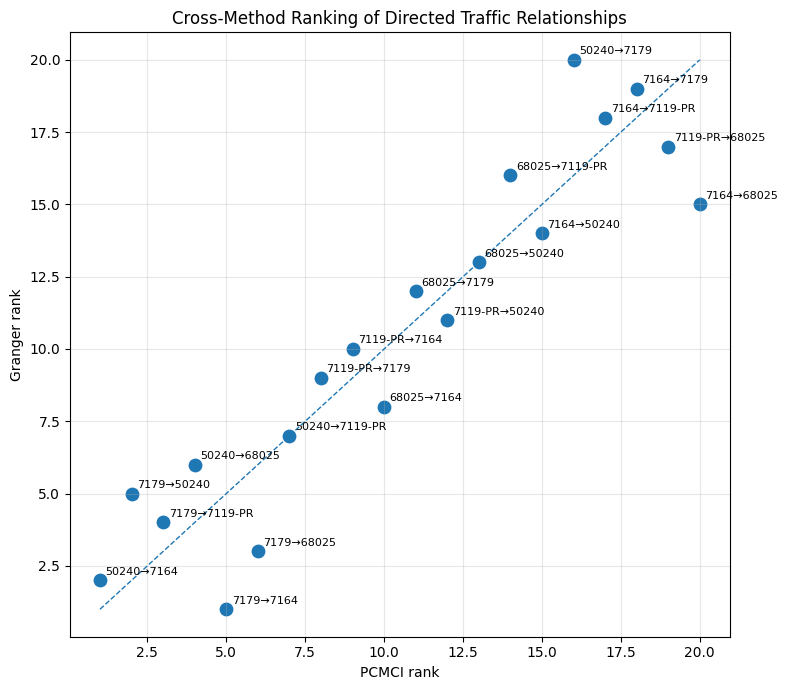

In [228]:
# Step 8.7 — Plot PCMCI rank vs Granger rank

plt.figure(figsize=(8, 7))

plt.scatter(
    rank_comparison["pcmci_rank"],
    rank_comparison["granger_rank"],
    s=80
)

for _, row in rank_comparison.iterrows():
    label = (
        f"{row['source_station']}"
        f"→{row['target_station']}"
    )

    plt.annotate(
        label,
        (
            row["pcmci_rank"],
            row["granger_rank"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

max_rank = max(
    rank_comparison["pcmci_rank"].max(),
    rank_comparison["granger_rank"].max()
)

plt.plot(
    [1, max_rank],
    [1, max_rank],
    linestyle="--",
    linewidth=1
)

plt.xlabel("PCMCI rank")
plt.ylabel("Granger rank")
plt.title(
    "Cross-Method Ranking of Directed Traffic Relationships"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "pcmci_granger_rank_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Visualize Incident and Causal Links on the Road Map

This final figure overlays the selected incident and local traffic stations.

In [229]:
# 9.1 — Prepare station coordinates and incident location

sensor_plot = sensor_meta.copy()

# Standardise coordinate column names
if "wgs84_latitude" in sensor_plot.columns:
    lat_col = "wgs84_latitude"
    lon_col = "wgs84_longitude"
elif "latitude" in sensor_plot.columns:
    lat_col = "latitude"
    lon_col = "longitude"
elif "Abs PM_x" in sensor_plot.columns:
    lat_col = "Abs PM_x"
    lon_col = "Abs PM_y"
else:
    raise ValueError("Cannot find latitude/longitude columns in sensor_meta")

sensor_plot["station_id"] = sensor_plot["station_id"].astype(str)

map_nodes = sensor_plot.merge(
    abnormal_summary[["station_id", "abnormal_pct_change", "abnormal_flow"]],
    on="station_id",
    how="left"
)

map_nodes

,station_id,wgs84_latitude,wgs84_longitude,road_name,suburb,post_code,device_type,quality_rating,lane_count,road_functional_hierarchy,distance_to_intersection,abnormal_pct_change,abnormal_flow
0,50240,-33.796436,150.987595,Briens Road,Northmead,2152,Tirtl,4,2,0,90.0,-56.670582,-477.710784
1,68025,-33.816696,150.976623,Great Western Highway,South Wentworthville,2145,Tirtl,4,2,5,240.0,112.235259,591.754902
2,7119-PR,-33.817974,150.981827,Hawkesbury Road,Merrylands,2160,Tirtl,5,2,0,10.0,42.061281,174.686275
3,7164,-33.815620,150.969238,Great Western Highway,South Wentworthville,2145,Tirtl,5,2,5,20.0,-63.444976,-165.750000
4,7179,-33.817272,150.962784,Jersey Road,South Wentworthville,2145,Tirtl,5,2,1,40.0,68.934826,600.250000


In [230]:
# 9.2 — Get incident coordinates

incident_rows = incidents_local[
    incidents_local["incident_id"] == selected_incident
].copy()

if len(incident_rows) == 0:
    raise ValueError("Selected incident not found in incidents_local")

incident_lat = incident_rows["Abs PM_x"].iloc[0]
incident_lon = incident_rows["Abs PM_y"].iloc[0]

print("Incident location:")
print("Latitude :", incident_lat)
print("Longitude:", incident_lon)

Incident location:
Latitude : -33.817974
Longitude: 150.981827


In [231]:
def plot_folium_station_incident_map(
    station_info,
    incident_lat,
    incident_lon,
    selected_incident,
    selected_station,
    save_name="case_with_incident_map.html"
):
    m = folium.Map(
        location=[
            station_info["wgs84_latitude"].mean(),
            station_info["wgs84_longitude"].mean()
        ],
        zoom_start=14,
        tiles="OpenStreetMap"
    )

    # Add station markers
    for _, row in station_info.iterrows():
        if np.isnan(row["wgs84_latitude"]) or np.isnan(row["wgs84_longitude"]):
            continue

        station_id = str(row["station_id"])

        popup_text = f"""
        <b>Station:</b> {station_id}<br>
        <b>Road:</b> {row.get("road_name", "N/A")}<br>
        <b>Suburb:</b> {row.get("suburb", "N/A")}<br>
        <b>Traffic change:</b> {row.get("abnormal_pct_change", np.nan):.1f}%<br>
        <b>Abnormal flow:</b> {row.get("abnormal_flow", np.nan):.1f} veh/hour
        """

        folium.Marker(
            location=[row["wgs84_latitude"], row["wgs84_longitude"]],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=f"Station {station_id}",
            icon=folium.Icon(color="blue", icon="info-sign")
        ).add_to(m)

        # Station label
        folium.Marker(
            location=[row["wgs84_latitude"], row["wgs84_longitude"]],
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    font-size: 12px;
                    font-weight: bold;
                    color: black;
                    background-color: white;
                    border: 1px solid black;
                    padding: 2px;
                    border-radius: 3px;">
                    {station_id}
                </div>
                """
            )
        ).add_to(m)

    # Add incident marker
    folium.Marker(
        location=[incident_lat, incident_lon],
        popup=folium.Popup(
            f"""
            <b>Incident:</b> {selected_incident}<br>
            <b>Matched station:</b> {selected_station}
            """,
            max_width=300
        ),
        tooltip=f"Incident: {selected_incident}",
        icon=folium.Icon(color="red", icon="star")
    ).add_to(m)

    # Click to show lat/lon
    m.add_child(folium.LatLngPopup())

    m.save(save_name)

    return m

In [232]:
m = plot_folium_station_incident_map(
    station_info=map_nodes,
    incident_lat=incident_lat,
    incident_lon=incident_lon,
    selected_incident=selected_incident,
    selected_station=selected_station,
    save_name=FIG_DIR / "case_with_incident_map.html"
)

m

## 10. Local Incident Benchmark Report

This final section summarizes the selected incident, station-level traffic anomalies, the strongest PCMCI relationships, and the overall agreement between PCMCI and Granger causality.

In [233]:
# Build concise station-level incident summary

local_incident_summary = final_interpretation.copy()

# Ensure station IDs use a consistent type
local_incident_summary["station_id"] = (
    local_incident_summary["station_id"].astype(str)
)

# Mark the matched incident station
local_incident_summary["is_incident_station"] = (
    local_incident_summary["station_id"]
    == str(selected_station)
)


# Classify anomaly magnitude and direction
def classify_traffic_anomaly(pct_change):
    if pd.isna(pct_change):
        return "Unavailable"
    elif pct_change >= 100:
        return "Extremely above baseline"
    elif pct_change >= 50:
        return "Strongly above baseline"
    elif pct_change >= 20:
        return "Moderately above baseline"
    elif pct_change > -20:
        return "Near baseline"
    elif pct_change > -50:
        return "Moderately below baseline"
    elif pct_change > -100:
        return "Strongly below baseline"
    else:
        return "Extremely below baseline"


local_incident_summary["traffic_anomaly_category"] = (
    local_incident_summary["abnormal_pct_change"]
    .apply(classify_traffic_anomaly)
)

In [234]:
# Format strongest incoming and outgoing PCMCI relationships

def format_incoming_link(row):
    source = row.get("strongest_incoming_from")

    if pd.isna(source):
        return "None retained"

    return (
        f"{source} → {row['station_id']} "
        f"(lag {int(row['incoming_lag_hour'])} h, "
        f"effect {row['incoming_effect']:.3f})"
    )


def format_outgoing_link(row):
    target = row.get("strongest_outgoing_to")

    if pd.isna(target):
        return "None retained"

    return (
        f"{row['station_id']} → {target} "
        f"(lag {int(row['outgoing_lag_hour'])} h, "
        f"effect {row['outgoing_effect']:.3f})"
    )


local_incident_summary["strongest_incoming_link"] = (
    local_incident_summary.apply(
        format_incoming_link,
        axis=1
    )
)

local_incident_summary["strongest_outgoing_link"] = (
    local_incident_summary.apply(
        format_outgoing_link,
        axis=1
    )
)

In [235]:
# Build cautious station-level interpretation

def build_station_interpretation(row):
    pct = row["abnormal_pct_change"]
    anomaly_category = row["traffic_anomaly_category"]

    if row["is_incident_station"]:
        location_text = "This is the matched incident station."
    else:
        location_text = "This is a neighbouring station."

    causal_parts = []

    if row["strongest_incoming_link"] != "None retained":
        causal_parts.append(
            "strongest incoming relationship: "
            f"{row['strongest_incoming_link']}"
        )

    if row["strongest_outgoing_link"] != "None retained":
        causal_parts.append(
            "strongest outgoing relationship: "
            f"{row['strongest_outgoing_link']}"
        )

    if causal_parts:
        causal_text = "; ".join(causal_parts)
    else:
        causal_text = (
            "no strong cross-station relationship was retained"
        )

    return (
        f"{location_text} "
        f"Traffic was {anomaly_category.lower()} "
        f"({pct:+.1f}% relative to the historical baseline). "
        f"Historical PCMCI context: {causal_text}."
    )


local_incident_summary["summary_interpretation"] = (
    local_incident_summary.apply(
        build_station_interpretation,
        axis=1
    )
)

In [236]:
# Select final local incident summary columns

required_summary_columns = [
    "station_id",
    "is_incident_station",
    "observed_incident_mean",
    "historical_incident_mean",
    "abnormal_flow",
    "abnormal_pct_change",
    "traffic_anomaly_category",
    "strongest_incoming_link",
    "strongest_outgoing_link",
    "summary_interpretation",
]

missing_summary_columns = [
    column
    for column in required_summary_columns
    if column not in local_incident_summary.columns
]

if missing_summary_columns:
    raise KeyError(
        "Cannot create local_incident_summary_table. "
        f"Missing columns: {missing_summary_columns}"
    )


local_incident_summary_table = (
    local_incident_summary[
        required_summary_columns
    ]
    .copy()
    .sort_values(
        [
            "is_incident_station",
            "abnormal_pct_change",
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)

In [237]:
# Prepare final station-level summary

final_benchmark_report = local_incident_summary_table.copy()

if "abs_abnormal_pct_change" not in final_benchmark_report.columns:
    final_benchmark_report["abs_abnormal_pct_change"] = (
        final_benchmark_report["abnormal_pct_change"].abs()
    )


final_benchmark_report = (
    final_benchmark_report
    .sort_values(
        ["is_incident_station", "abs_abnormal_pct_change"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)

display(
    final_benchmark_report[
        [
            "station_id",
            "is_incident_station",
            "observed_incident_mean",
            "historical_incident_mean",
            "abnormal_flow",
            "abnormal_pct_change",
            "traffic_anomaly_category",
            "strongest_incoming_link",
            "strongest_outgoing_link",
            "summary_interpretation",
        ]
    ]
)

,station_id,is_incident_station,observed_incident_mean,historical_incident_mean,abnormal_flow,abnormal_pct_change,traffic_anomaly_category,strongest_incoming_link,strongest_outgoing_link,summary_interpretation
0,7119-PR,True,590.00,415.313725,174.686275,42.061281,Moderately above baseline,"7179 → 7119-PR (lag 1 h, effect 0.132)","7119-PR → 7179 (lag 1 h, effect 0.111)","This is the matched incident station. Traffic was moderately above baseline (+42.1% relative to the historical baseline). Historical PCMCI context: strongest incoming relationship: 7179 → 7119-PR (lag 1 h, effect 0.132); strongest outgoing relationship: 7119-PR → 7179 (lag 1 h, effect 0.111)."
1,68025,False,1119.00,527.245098,591.754902,112.235259,Extremely above baseline,"50240 → 68025 (lag 1 h, effect 0.130)",None retained,"This is a neighbouring station. Traffic was extremely above baseline (+112.2% relative to the historical baseline). Historical PCMCI context: strongest incoming relationship: 50240 → 68025 (lag 1 h, effect 0.130)."
2,7179,False,1471.00,870.750000,600.250000,68.934826,Strongly above baseline,"7119-PR → 7179 (lag 1 h, effect 0.111)","7179 → 50240 (lag 1 h, effect 0.133)","This is a neighbouring station. Traffic was strongly above baseline (+68.9% relative to the historical baseline). Historical PCMCI context: strongest incoming relationship: 7119-PR → 7179 (lag 1 h, effect 0.111); strongest outgoing relationship: 7179 → 50240 (lag 1 h, effect 0.133)."
3,7164,False,95.50,261.250000,-165.750000,-63.444976,Strongly below baseline,"50240 → 7164 (lag 1 h, effect 0.145)",None retained,"This is a neighbouring station. Traffic was strongly below baseline (-63.4% relative to the historical baseline). Historical PCMCI context: strongest incoming relationship: 50240 → 7164 (lag 1 h, effect 0.145)."
4,50240,False,365.25,842.960784,-477.710784,-56.670582,Strongly below baseline,"7179 → 50240 (lag 1 h, effect 0.133)","50240 → 7164 (lag 1 h, effect 0.145)","This is a neighbouring station. Traffic was strongly below baseline (-56.7% relative to the historical baseline). Historical PCMCI context: strongest incoming relationship: 7179 → 50240 (lag 1 h, effect 0.133); strongest outgoing relationship: 50240 → 7164 (lag 1 h, effect 0.145)."


In [238]:
# Identify main anomaly findings

largest_positive = final_benchmark_report.loc[
    final_benchmark_report["abnormal_pct_change"].idxmax()
]

largest_negative = final_benchmark_report.loc[
    final_benchmark_report["abnormal_pct_change"].idxmin()
]

positive_stations = final_benchmark_report[
    final_benchmark_report["abnormal_pct_change"] > 0
].copy()

negative_stations = final_benchmark_report[
    final_benchmark_report["abnormal_pct_change"] < 0
].copy()

print(
    "Largest positive anomaly:",
    largest_positive["station_id"],
    f"{largest_positive['abnormal_pct_change']:+.1f}%"
)

print(
    "Largest negative anomaly:",
    largest_negative["station_id"],
    f"{largest_negative['abnormal_pct_change']:+.1f}%"
)

print(
    "Stations above baseline:",
    positive_stations["station_id"].astype(str).tolist()
)

print(
    "Stations below baseline:",
    negative_stations["station_id"].astype(str).tolist()
)

Largest positive anomaly: 68025 +112.2%
Largest negative anomaly: 7164 -63.4%
Stations above baseline: ['7119-PR', '68025', '7179']
Stations below baseline: ['7164', '50240']


In [239]:
# Print final local incident benchmark report

print("LOCAL INCIDENT CAUSAL BENCHMARK REPORT")

print(f"Selected incident       : {selected_incident}")
print(f"Incident station        : {selected_station}")
print(f"Incident period         : {incident_start} to {incident_end}")
print(f"Stations analysed       : {len(final_benchmark_report)}")
print(f"Historical observations : {len(flow_matrix)}")
print(f"Maximum causal lag      : {tau_max} hours")

print()
print("CROSS-METHOD ROBUSTNESS")
print(f"PCMCI directed pairs   : {len(pcmci_ranked)}")
print(f"Granger directed pairs : {len(granger_ranked)}")

print()

print("Agreement across ranking thresholds")

for _, row in top_k_overlap.iterrows():

    print(
        f"Top-{int(row['top_k']):<2} : "
        f"{int(row['shared_links'])}/{int(row['top_k'])} shared "
        f"({row['overlap_rate']:.1%})"
    )

print()

print(f"Spearman rank correlation : {spearman_rho:.3f}")
print(f"Spearman p-value          : {spearman_p:.3e}")

print()

print()
print("TRAFFIC RESPONSE SUMMARY")

for _, row in (
    final_benchmark_report
    .sort_values("abnormal_pct_change", ascending=False)
    .iterrows()
):
    marker = "*" if row["is_incident_station"] else " "

    print(
        f"{marker} Station {row['station_id']}: "
        f"{row['abnormal_pct_change']:+.1f}% "
        f"({row['traffic_anomaly_category']})"
    )

print()
print("STATION-LEVEL PCMCI INTERPRETATION")

for _, row in final_benchmark_report.iterrows():
    print()
    print(f"Station {row['station_id']}")
    print("-" * 45)

    print(
        f"Incident station : "
        f"{row['is_incident_station']}"
    )

    print(
        f"Traffic anomaly  : "
        f"{row['abnormal_pct_change']:+.1f}% "
        f"({row['traffic_anomaly_category']})"
    )

    print(
        f"Incoming link    : "
        f"{row['strongest_incoming_link']}"
    )

    print(
        f"Outgoing link    : "
        f"{row['strongest_outgoing_link']}"
    )

    print(
        f"Interpretation   : "
        f"{row['summary_interpretation']}"
    )

print()
print("OVERALL FINDINGS")

print(
    f"- The incident station {selected_station} experienced "
    f"{final_benchmark_report.loc[
        final_benchmark_report['station_id'].astype(str)
        == str(selected_station),
        'abnormal_pct_change'
    ].iloc[0]:+.1f}% traffic relative to its historical baseline."
)

print(
    f"- The largest positive anomaly occurred at station "
    f"{largest_positive['station_id']} "
    f"({largest_positive['abnormal_pct_change']:+.1f}%)."
)

print(
    f"- The largest traffic reduction occurred at station "
    f"{largest_negative['station_id']} "
    f"({largest_negative['abnormal_pct_change']:+.1f}%)."
)


print(
    f"- The full rankings were strongly associated "
    f"(Spearman rho = {spearman_rho:.3f})."
)

LOCAL INCIDENT CAUSAL BENCHMARK REPORT
Selected incident       : 240298-webtirf
Incident station        : 7119-PR
Incident period         : 2025-06-26 08:00:00 to 2025-06-26 11:00:00
Stations analysed       : 5
Historical observations : 8760
Maximum causal lag      : 6 hours

CROSS-METHOD ROBUSTNESS
PCMCI directed pairs   : 20
Granger directed pairs : 20

Agreement across ranking thresholds
Top-3  : 1/3 shared (33.3%)
Top-5  : 4/5 shared (80.0%)
Top-8  : 7/8 shared (87.5%)
Top-10 : 10/10 shared (100.0%)
Top-15 : 14/15 shared (93.3%)
Top-20 : 20/20 shared (100.0%)

Spearman rank correlation : 0.925
Spearman p-value          : 5.539e-09


TRAFFIC RESPONSE SUMMARY
  Station 68025: +112.2% (Extremely above baseline)
  Station 7179: +68.9% (Strongly above baseline)
* Station 7119-PR: +42.1% (Moderately above baseline)
  Station 50240: -56.7% (Strongly below baseline)
  Station 7164: -63.4% (Strongly below baseline)

STATION-LEVEL PCMCI INTERPRETATION

Station 7119-PR
-----------------------